---
title: From Tidy to Wide Without Aggregating
subtitle: DS 2023 | Communicating with Data
---

## Overview

The previous notebook, **Two Ways from Tidy to Wide**, assumed the following:

- You have a tidy DataFrame $D$ with two grouping variables $g_1$ and $g_2$ and one measurement variable $m$.

- You want a wide table $W$ with $g_1$ on axis 0, $g_2$ on axis 1, and $m$ in the cells.

It then split on a single condition: do $g_1$ and $g_2$ combine to produce a unique set over the observations?

- If yes, reshape.

- If no, aggregate and reshape.

This notebook adds a third method, for the case where **aggregating is not acceptable**.

You want to widen the table, but you need to keep every observation, so collapsing each group to a single value is not an option.

The condition for this notebook is therefore the following:

- You have a tidy DataFrame $D$ with one or more grouping variables, which we refer to collectively as $g$, and one measurement variable $m$.

- The values of $g$ do **not** form a unique key over $D$. Some combination of them occurs more than once.

- Aggregating is not acceptable, because you need every observation.

- You want a wide table $W$ with the levels of $g$ on axis 1 and every value of $m$ running down the columns.

The number of grouping variables does not matter here.

What matters is that they fail to identify a row.

A single variable may fail, as `species` does in `iris` below, and so may a combination, as `species` and `sex` do in `penguins`.

The solution is to manufacture one more grouping variable, chosen so that it completes the key.

We will call it $w$, a **within-group ID**.

Once $w$ exists, $w \times g$ is unique, and the two methods from the previous notebook apply unchanged.

$w$ goes on axis 0 and $g$ goes on axis 1.

### Two use cases

The method has two quite different uses, and it is worth knowing which one you are in.

**The position within the group is arbitrary.**

This is the case in `iris` below, where the seventh setosa has nothing to do with the seventh virginica.

Here the wide table is a convenience rather than a necessity.

Both Pandas and Seaborn will plot the data without it, as we will see.

What the wide table gives you is a compact, readable table instead of a very sparse one, and that matters more as the number of groups grows.

**The position within the group is meaningful.**

This happens when row order records something that the table never gave a column, such as repeated measurements on a subject, successive readings from an instrument, or the order of a ranked list.

Here the wide table is necessary, because the comparison you want to make runs across a row.

We take up this case at the end of the notebook.

### Two preconditions

Before manufacturing anything, we check two things about $g$.

Both are quick, and both are checked the same way in every example below.

1. **$g$ is not a key.** If it were a key, you would reshape directly and this notebook would not apply.

2. **$g$ is complete.** Every row must have a value for $g$. The `.groupby()` method ignores rows whose grouping value is missing, so those rows receive no within-group ID, and a $w$ with gaps in it is not a key. Decide what to do about those rows before reshaping, not after the reshape fails.

## Flowchart

This flowchart extends the one from the previous notebook.

The completeness check and the second decision are new.

```mermaid
flowchart TD

    A["Check that g is complete<br>D[g].isna().sum() == 0"]

    A -->|"incomplete"| B["Decide and act now:<br>drop the rows, or give them<br>an explicit group label"]

    A --> C["Check if g1 x g2 combinations are unique over D by using D.value_counts(['g1','g2'])"]

    B --> C

    C --> D{"Does every count == 1?"}

    D -->|"Yes: each pair occurs<br>at most once"| E["Pure reshape<br>(see Two Ways from Tidy to Wide)"]

    D -->|"No: some pairs repeat"| F{"Aggregate or transform?"}

    F -->|"Aggregate:<br>collapse each group<br>to one value"| G["Aggregate and reshape<br>(see Two Ways from Tidy to Wide)"]

    F -->|"Transform:<br>keep every row"| H["Manufacture w with a transformation,<br>so that w x g becomes unique<br>D['w'] = D.groupby(g).cumcount()"]

    H --> H1["D.pivot(index='w',<br>columns='g',<br>values='m')"]

    H --> H2["D.set_index(['w','g'])['m']<br>.unstack('g')"]

    H1 --> Z["W: rows = position within group, cols = G levels, cells = M"]

    H2 --> Z

    classDef unique fill:#d8f0d8,stroke:#4a8a4a,color:#1c3a1c
    classDef dup fill:#fde4d4,stroke:#c07a45,color:#4a2a12
    classDef new fill:#d9e6f7,stroke:#41689e,color:#16283f
    classDef pre fill:#efe6f7,stroke:#7a5aa0,color:#2b1c3d
    class A,B pre
    class E unique
    class G dup
    class H,H1,H2 new
```

## Example 1

We use `iris`, which records four measurements for $150$ flowers of three species.

### Get the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Choose the variables

Here $g$ is a single variable.

We assign it and $m$.

In [2]:
a_g = 'species'
a_m = 'petal_length'

### Check the preconditions

We check completeness first.

In [3]:
iris[a_g].isna().sum()

np.int64(0)

There are no missing values, so every row will receive a number.

Now we check uniqueness.

This is the same check as in the previous notebook, applied to whatever $g$ happens to be.

Value counts returns results in descending order, so any values greater than 1 would appear first.

In [4]:
iris.value_counts([a_g]).head(1)

species
setosa     50
Name: count, dtype: int64

The variable is not unique, because each species occurs $50$ times.

By the previous notebook we would now aggregate.

But we want a box plot, so we need all $150$ measurements.

We continue down the new branch.

### What pivot does without an index

We first look at what Pandas does when we ask for the reshape and give it no index.

In [5]:
staircase = iris.pivot(columns=a_g, values=a_m)

print('shape:      ', staircase.shape)
print('total cells:', staircase.size)
print('cells filled:', staircase.notna().sum().sum())

staircase.iloc[48:53]

shape:       (150, 3)
total cells: 450
cells filled: 150


species,setosa,versicolor,virginica
48,1.5,NaN,NaN
49,1.4,NaN,NaN
50,NaN,4.7,NaN
51,NaN,4.5,NaN
52,NaN,4.9,NaN


Pandas raised no error, and the result is a legitimate table.

Lacking an index, it used the dataframe's original row numbers.

Every original row number belongs to exactly one species, so each row holds one value and two blanks.

The result is $150$ values arranged as a staircase across $450$ cells.

This table is sparse, not wrong, and it is worth being clear about what the sparseness costs.

It does not cost us the plot.

A box plot drawn from the staircase is identical to one drawn from the compact table we are about to build, because plotting functions ignore missing values.

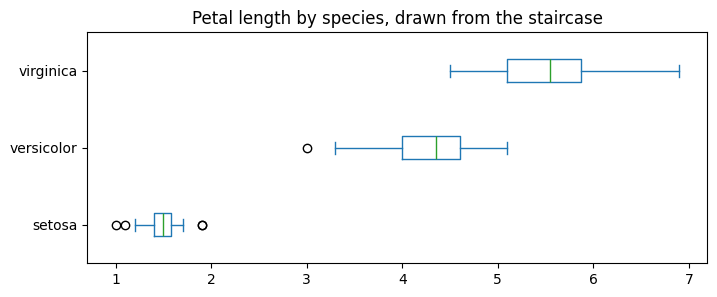

In [6]:
staircase.plot.box(vert=False, figsize=(8, 3))
plt.title('Petal length by species, drawn from the staircase')
plt.show()

What the sparseness costs is space.

The staircase has one row per observation and one column per group, so its size grows with the number of groups.

For the three species of `iris` that means $450$ cells to hold $150$ values.

For the $194$ pickup zones of the `taxis` data it would mean over a million cells to hold about six thousand values.

So the compact table is worth building when you want to read the table, export it, or when the number of groups is large.

What we need for that is a row label meaning **the nth flower of its species**, so that the first setosa, the first versicolor, and the first virginica all land on row $0$.

### Manufacture $w$

Recall that `groupby` operations fall into three families, according to the shape of what they return:

- **Aggregate** returns one row per group, as in `.mean()`, `.sum()`, and `.count()`.
- **Transform** returns one row per *original* row, aligned to the index, as in `.rank()`, `.cumsum()`, and `.shift()`.
- **Filter** returns a subset of the original rows.

This is the difference between the previous notebook's second case and this one.

That case aggregates, which collapses each group to a single value.

This case transforms, which gives every row a value and keeps all of them.

The transformation we want is `.cumcount()`, which numbers the rows within each group, starting at $0$ and starting over at each new group.

In [7]:
a_w = 'within_group_id'

iris[a_w] = iris.groupby(a_g).cumcount()

The behavior to notice is what happens at a group boundary.

The `iris` data is ordered by species, so the change occurs at row $50$.

In [8]:
iris.loc[48:52, [a_g, a_m, a_w]]

,species,petal_length,within_group_id
48,setosa,1.5,48
49,setosa,1.4,49
50,versicolor,4.7,0
51,versicolor,4.5,1
52,versicolor,4.9,2


> [!NOTE] The `.cumcount()` method is already a transformation, so it does not need to be wrapped in `.transform()`.
>
> The call `D.groupby(g).transform('cumcount')` returns exactly the same values.
>
> The extra call adds a step and nothing else.

The counter reaches $49$ at the last setosa and resets to $0$ at the first versicolor.

Each species is therefore numbered $0$ through $49$, and $w \times g$ is now unique.

We can verify this with the same check we used above.

In [9]:
iris.value_counts([a_w, a_g]).head(1)

within_group_id  species
0                setosa     1
Name: count, dtype: int64

### Reshape

Having manufactured $w$, both methods from the previous notebook apply unchanged.

We put $w$ in the $g_1$ position and $g$ in the $g_2$ position.

#### Method 1: Pivoting

In [10]:
iris.pivot(index=a_w, columns=a_g, values=a_m).head()

species,setosa,versicolor,virginica
within_group_id,,,
0,1.4,4.7,6.0
1,1.4,4.5,5.1
2,1.3,4.9,5.9
3,1.5,4.0,5.6
4,1.4,4.6,5.8


#### Method 2: Unstacking

In [11]:
iris.set_index([a_w, a_g])[a_m].unstack().head()

species,setosa,versicolor,virginica
within_group_id,,,
0,1.4,4.7,6.0
1,1.4,4.5,5.1
2,1.3,4.9,5.9
3,1.5,4.0,5.6
4,1.4,4.6,5.8


The staircase has collapsed from $150$ rows into $50$, with every cell filled.

$W$ is now in the shape our plotting functions expect.

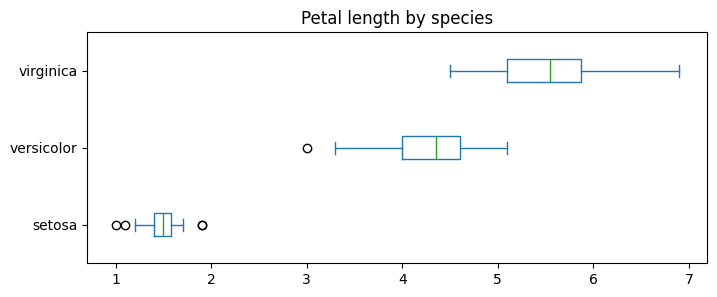

In [12]:
iris.pivot(index=a_w, columns=a_g, values=a_m).plot.box(vert=False, figsize=(8, 3))
plt.title('Petal length by species')
plt.show()

## Example 2: groups of different sizes

The `iris` data is unusually regular.

It has exactly $50$ flowers per species, no missing values, and rows already ordered by group.

Most data is not like this.

The next three examples each introduce one way that it is not, using `penguins`.

This first one is the mildest of the three, because the only difference is that the three species are of different sizes.

### Get the data

In [13]:
penguins = sns.load_dataset('penguins')

print(penguins.species.value_counts().to_string())
penguins.head()

species
Adelie       152
Gentoo       124
Chinstrap     68


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### Choose the variables

In [14]:
b_w = 'within_group_id'
b_g = 'species'
b_m = 'body_mass_g'

### Check the preconditions

In [15]:
print('missing values in g:', penguins[b_g].isna().sum())

penguins.value_counts([b_g]).head(1)

missing values in g: 0


species
Adelie     152
Name: count, dtype: int64

The variable is complete, and it is not unique.

Both preconditions behave as they did in Example 1, so we proceed in the same way.

In [16]:
penguins[b_w] = penguins.groupby(b_g).cumcount()

mass_by_species = penguins.pivot(index=b_w, columns=b_g, values=b_m)

print('shape:', mass_by_species.shape)
mass_by_species.tail(3)

shape: (152, 3)


species,Adelie,Chinstrap,Gentoo
within_group_id,,,
149,3750.0,NaN,NaN
150,3700.0,NaN,NaN
151,4000.0,NaN,NaN


### The result is ragged

$W$ has as many rows as the largest group, which is $152$.

The shorter columns are padded with `NaN` at the bottom.

This is expected and harmless.

Pandas' plotting functions ignore missing values, so each plot is drawn only from the observations that exist.

species
Adelie       151
Chinstrap     68
Gentoo       123


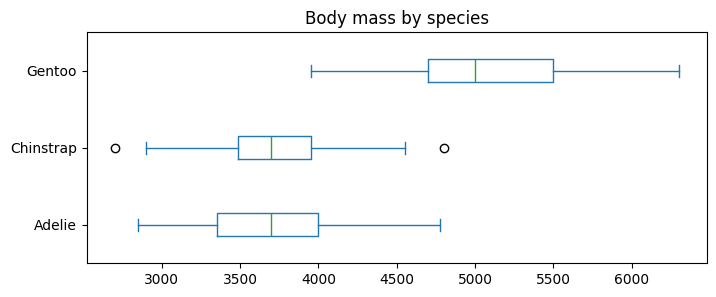

In [17]:
print(mass_by_species.count().to_string())

mass_by_species.plot.box(vert=False, figsize=(8, 3))
plt.title('Body mass by species')
plt.show()

> [!NOTE] The counts above are $151$, $68$, and $123$, not $152$, $68$, and $124$.
>
> Two penguins have no recorded body mass.
>
> That is missingness in $m$, not in $g$, and it is harmless here, because those rows occupy a row of $W$ and contribute a `NaN` to it.
>
> Only missingness in $g$ breaks the method, which is why the precondition concerns $g$ alone.

## Example 3: an incomplete grouping variable

We now take a grouping variable that is not complete.

We stay with a single column so that nothing else is in play.

### Choose the variables

In [18]:
c_w = 'within_group_id'
c_g = 'sex'
c_m = 'body_mass_g'

### Check the preconditions

In [19]:
print('missing values in g:', penguins[c_g].isna().sum())

penguins.value_counts([c_g]).head(1)

missing values in g: 11


sex 
Male    168
Name: count, dtype: int64

The variable is not unique, as expected.

But $11$ rows have no value for `sex`, so the completeness precondition fails.

It is worth seeing what that costs, because the error we eventually get does not describe the problem.

In [20]:
penguins[c_w] = penguins.groupby(c_g).cumcount()

penguins.loc[penguins[c_g].isna(), ['species', c_g, c_w]].head()

,species,sex,within_group_id
3,Adelie,NaN,NaN
8,Adelie,NaN,NaN
9,Adelie,NaN,NaN
10,Adelie,NaN,NaN
11,Adelie,NaN,NaN


The `.groupby()` method ignored those rows, so `.cumcount()` had no number to give them, and every one of them received `NaN`.

Eleven rows now share the same index value, and the reshape fails.

In [21]:
try:
    penguins.pivot(index=c_w, columns=c_g, values=c_m)
except ValueError as e:
    print('ValueError:', e)

ValueError: Index contains duplicate entries, cannot reshape


The message names duplicate entries in the index.

That is accurate, but it does not say that the duplicates are the missing values.

### Handling it

The decision is yours to make, and it is a decision about the data rather than about Pandas.

- **Drop the rows.** This is correct when a penguin of unrecorded sex belongs in neither column.
- **Give them an explicit label.** This is correct when "unknown" is itself a group worth seeing.

Here we drop them.

Note the order of operations: we assign $w$ first, then drop, then reshape.

Dropping first would also work, but it would change the dataframe we are working with, and $D$ should stay intact.

In [22]:
mass_by_sex = penguins.dropna(subset=[c_g]).pivot(
    index=c_w, columns=c_g, values=c_m)

mass_by_sex.count()

sex
Female    165
Male      168
dtype: int64

> [!CAUTION] Run this check before you reshape, not after.
>
> A reshape that fails is easy to notice.
>
> A grouping variable whose missing rows were quietly excluded is not, and it leaves $W$ describing fewer observations than you think it does.

## Example 4: several grouping variables

Nothing in the method requires $g$ to be a single column.

We pass a list to `.groupby()` and to `columns`, and the result carries a hierarchical column index.

The preconditions are checked in the same way as before.

We already know from Example 3 that `sex` is incomplete, so we handle that first, and nothing about it is new here.

### Choose the variables

In [23]:
d_w = 'within_group_id'
d_g = ['species', 'sex']
d_m = 'body_mass_g'

### Check the preconditions

In [24]:
print('missing values in g:')
print(penguins[d_g].isna().sum().to_string())

penguins.value_counts(d_g).head(1)

missing values in g:
species     0
sex        11


species  sex 
Adelie   Male    73
Name: count, dtype: int64

The variable `species` is complete and `sex` is not, so the same eleven rows are removed.

The reshape then proceeds as in every other example.

In [25]:
penguins[d_w] = penguins.groupby(d_g).cumcount()

mass_by_group = penguins.dropna(subset=d_g).pivot(
    index=d_w, columns=d_g, values=d_m)

mass_by_group.count()

species    sex   
Adelie     Male      73
           Female    73
Chinstrap  Female    34
           Male      34
Gentoo     Female    58
           Male      61
dtype: int64

The column index now has one level per grouping variable.

If you would rather have flat labels, combine the grouping variables into a single column before grouping.

The `.str.cat()` method does this, and it returns `NaN` wherever either part is missing.

That means the completeness check then covers the combination in one step.

In [26]:
penguins['group'] = penguins.species.str.cat(penguins.sex, sep=' ')

print('missing values in the combined g:', penguins['group'].isna().sum())

penguins[d_w] = penguins.groupby('group').cumcount()

penguins.dropna(subset=['group']).pivot(
    index=d_w, columns='group', values=d_m).count()

missing values in the combined g: 11


group
Adelie Female       73
Adelie Male         73
Chinstrap Female    34
Chinstrap Male      34
Gentoo Female       58
Gentoo Male         61
dtype: int64

## What $W$ means when the position is arbitrary

In all four examples above, $w$ is a position and not a measurement.

It carries no information about the observation.

This limits how $W$ may be used.

> [!WARNING] The rows of $W$ are not aligned in any meaningful way.
>
> The setosa on row $7$ has nothing to do with the virginica on row $7$.
>
> Each is simply the eighth flower of its species in the order the file happened to list them.
>
> It would be a mistake to subtract one column from another, to correlate them, or to treat a row as an observation.

Compare this with the wide table from the previous notebook, where row $1970$ means the year 1970 in every column.

There, reading across a row is meaningful.

Here it is not.

A $W$ built on an arbitrary index is a convenience, not a tidy dataset.

Build it, use it, and return to $D$ for anything else.

The next section takes up the case where none of this applies.

## When the position is meaningful

Everything above assumed that a row's position within its group is arbitrary.

Sometimes it is not.

Row order can record something that the table never gave a column, such as repeated measurements on a subject, successive readings from an instrument, or the order of a ranked list.

Consider a small table of scores, three per subject, recorded in visit order.

In [27]:
scores = pd.DataFrame({
    'subject': np.repeat(['s1', 's2', 's3'], 3),
    'score':   [10, 14, 19, 8, 12, 15, 11, 13, 18],
})

scores

,subject,score
0,s1,10
1,s1,14
2,s1,19
3,s2,8
4,s2,12
5,s2,15
6,s3,11
7,s3,13
8,s3,18


The visit number is present in this data, but only as row order.

The same `.cumcount()` call recovers it as a column.

We add $1$ to the count, because visits are numbered from one.

In [28]:
scores['visit'] = scores.groupby('subject').cumcount() + 1

visits_wide = scores.pivot(index='subject', columns='visit', values='score')
visits_wide

visit,1,2,3
subject,,,
s1,10,14,19
s2,8,12,15
s3,11,13,18


This is the same method as before, but what it produces is different.

The column index is now `visit`, which is a real variable, and each row is one subject.

That makes $W$ a tidy table rather than a convenience, and it makes reading across a row meaningful.

In [29]:
visits_wide[3] - visits_wide[1]

subject
s1    9
s2    7
s3    7
dtype: int64

The change from the first visit to the third is a quantity we can compute only in this shape.

In the arbitrary case that subtraction would have been meaningless.

One point of practice follows from this.

When the position means something, name the column for what it means.

Call it `visit`, not `within_group_id`.

## Controlling the order

The `.cumcount()` method numbers rows in the order they appear in $D$.

It does not sort anything.

So if the numbering should mean something, sort $D$ first.

Sorting by the measurement, for example, makes each column of $W$ ascend.

In [30]:
iris_sorted = iris.sort_values([a_g, a_m])
iris_sorted[a_w] = iris_sorted.groupby(a_g).cumcount()

iris_sorted.pivot(index=a_w, columns=a_g, values=a_m).head()

species,setosa,versicolor,virginica
within_group_id,,,
0,1.0,3.0,4.5
1,1.1,3.3,4.8
2,1.2,3.3,4.8
3,1.2,3.5,4.9
4,1.3,3.5,4.9


For a box plot or a histogram this makes no difference, because those plots do not depend on the order in which the values arrive.

It matters when you want $W$ to be readable, or when you intend to take the first $n$ rows of each group.

### Numbering by a column without sorting

Sorting changes $D$.

If the numbering should follow a column but you would rather leave the dataframe as it arrived, use a different transformation.

The `.rank()` method assigns each row its position within its group under some ordering.

With `method='first'`, ties are broken by position rather than shared, so every row receives a distinct rank and $w \times g$ stays unique.

Ranks begin at $1$, so we subtract $1$ to match `.cumcount()`.

In [31]:
iris[a_w] = iris.groupby(a_g)[a_m].rank(method='first').astype(int) - 1

iris.pivot(index=a_w, columns=a_g, values=a_m).head()

species,setosa,versicolor,virginica
within_group_id,,,
0,1.0,3.0,4.5
1,1.1,3.3,4.8
2,1.2,3.3,4.8
3,1.2,3.5,4.9
4,1.3,3.5,4.9


This is the same $W$ that the sort produced, and $D$ is untouched.

Note that `.rank()` is a transformation as well.

The pattern generalizes: any groupby operation that returns one value per original row can serve as $w$, provided the values are distinct within each group.

## General Function

As before, we define a general function that takes a tidy dataframe as its first argument and returns a wide dataframe.

This one takes $g$ and $m$ only, because $w$ is manufactured rather than supplied.

In [32]:
def tidy2wide_all(tidy, g, m, w='within_group_id', method='pivot', sort_by=None):

    D = tidy.copy()

    # Sort first if the numbering should mean something
    if sort_by is not None:
        D = D.sort_values(sort_by)

    # Manufacture the index
    D[w] = D.groupby(g).cumcount()

    # Rows with a missing grouping value got no number, so remove them
    keys = [g] if isinstance(g, str) else list(g)
    D = D.dropna(subset=keys)

    if method == 'pivot':
        wide = D.pivot(index=w, columns=g, values=m)
    elif method == 'unstack':
        wide = D.set_index([w] + keys)[m].unstack(keys)
    else:
        raise ValueError("Invalid method.")

    return wide

In [33]:
tidy2wide_all(iris, 'species', 'petal_length').head()

species,setosa,versicolor,virginica
within_group_id,,,
0,1.4,4.7,6.0
1,1.4,4.5,5.1
2,1.3,4.9,5.9
3,1.5,4.0,5.6
4,1.4,4.6,5.8


In [34]:
tidy2wide_all(penguins, 'species', 'body_mass_g', method='unstack').count()

species
Adelie       151
Chinstrap     68
Gentoo       123
dtype: int64

In [35]:
tidy2wide_all(penguins, ['species', 'sex'], 'body_mass_g').count()

species    sex   
Adelie     Male      73
           Female    73
Chinstrap  Female    34
           Male      34
Gentoo     Female    58
           Male      61
dtype: int64

In [36]:
tidy2wide_all(iris, 'species', 'petal_length', sort_by=['species', 'petal_length']).head()

species,setosa,versicolor,virginica
within_group_id,,,
0,1.0,3.0,4.5
1,1.1,3.3,4.8
2,1.2,3.3,4.8
3,1.2,3.5,4.9
4,1.3,3.5,4.9


## Summary

:::{table}
| Condition | Method |
| --- | --- |
| $g_1 \times g_2$ is unique | `.pivot()` or `.set_index().unstack()` |
| Not unique, one summary value per cell is acceptable | `.pivot_table()` or `.groupby().unstack()` |
| Not unique, every observation must be kept | Manufacture $w$ with `.cumcount()`, then either method above |
:::

The third row covers two quite different situations.

When the position within a group is arbitrary, $W$ is a convenience, and you may not need it at all, since Pandas and Seaborn will both plot without it.

When the position is meaningful, $W$ is necessary, and the manufactured column is really a variable recovered from row order.

There are three things to remember about the method itself.

Check that $g$ is complete before anything else, because rows with no group receive no number, and a $w$ with gaps is not a key.

The variable $w$ comes from a transformation, not an aggregation, and that is what distinguishes this case from the previous notebook's second one.

The `.cumcount()` method numbers rows in the order they appear, so to number by a column instead, sort $D$ first or use `.rank(method='first')`, which leaves $D$ alone.